## Create the traffic simulator class

Here we will be running a simulation of a click / no click that a user on a site may go through. For this we will first start by defining the traffic simulator class which stores the simulated CTR rates calculated in the previous Python notebook.

In [85]:
import numpy as np
class TrafficSimulator:

    def __init__(self, true_ctrs, seed=42):

        # store the simulated ctr rates of each variant in dictionary
        self.true_ctrs = true_ctrs

        # for reproducability create rng
        self.rng = np.random.default_rng(seed)

    def simulate_click(self, variant : str) -> int:

        # if not a valid variant return
        if variant not in self.true_ctrs:
            print('This variant does not exist.')
            return -1
        
        # get the random number 
        random_no = self.rng.random()

        # returns 1 is lower than p else 0
        return int(random_no < self.true_ctrs[variant])

    def simulate_batch(self, variant: str, n: int) -> int:

        if variant not in self.true_ctrs:
            print('This variant does not exist.')
            return -1

        # return result
        return (self.rng.random(n) < self.true_ctrs[variant]).astype(int)


In [86]:
true_ctrs = {'A' : 0.657, 'B': 0.2120, 'C' : 0.2167}

## A/B Testing

Now, we will run three different types of A/B testing

### Classic A/B testing


In classic A/B testing, we first need to determine the number of users that we should run our sampling. This can be done using a power test which tells us at which sample number will our experiments haev statistical significance. We have set the minimum detectable effect at 10% meaning we want to see if the difference between variance is atleast 10% with a baseline ctr of 0.21.

Then using the sample size, we will run our simulation on the three variants and use the chi-squared test to determine whether the differences in click rates are significant or could be from random noise. This test will tell us only if atleast one of the three are significantly different. But to pin-point which pairs of the variants differ, we conduct z-tests across all three pairs, using a Bonferroni correction since the number of false positives risk increase when conducting individual tests, hence we lower the threshold.

In [87]:
import statsmodels.api as sm
import math

# conduct power analysis to see how many visits we want per variant

# calculate the effect size between A vs. B and B vs. C
effect_a_b = sm.stats.proportion_effectsize(true_ctrs['A'], true_ctrs['B'])
effect_b_c = sm.stats.proportion_effectsize(true_ctrs['B'], true_ctrs['C'])

nind_power = sm.stats.NormalIndPower()
# solve for the sample size for the two effect sizes
sample_a_b = math.ceil(nind_power.solve_power(effect_a_b, alpha=0.05, power=0.8))
sample_b_c = math.ceil(nind_power.solve_power(effect_b_c, alpha=0.05, power=0.8))

print(f'A vs. B Sample Size {sample_a_b}')
print(f'B vs. C Sample Size {sample_b_c}')

A vs. B Sample Size 19
B vs. C Sample Size 119670


In [88]:
# calculate the sample size for the simulation for testing
# use a MDE (minimum detectable effect of 10% and base ctr of 0.21 (around the B and C ctrs))

effect_size = sm.stats.proportion_effectsize(0.21, 0.231)
sample_size = math.ceil(nind_power.solve_power(effect_size, alpha=0.05, power=0.8))
print(f'Sample Size {sample_size}')

Sample Size 6116


In [89]:
from scipy.stats import chi2_contingency
# simulate responses for all three variants

trafficsim_classic = TrafficSimulator(true_ctrs=true_ctrs)
sim_a = trafficsim_classic.simulate_batch('A', 6116)
sim_b = trafficsim_classic.simulate_batch('B', 6116)
sim_c = trafficsim_classic.simulate_batch('C', 6116)

# conduct chi-squared test on all three 
contingency_table = [[np.count_nonzero(sim_a), 6116 - np.count_nonzero(sim_a)], 
                     [np.count_nonzero(sim_b), 6116 - np.count_nonzero(sim_b)],
                     [np.count_nonzero(sim_c), 6116 - np.count_nonzero(sim_c)]]

chi_res = chi2_contingency(contingency_table)

In [90]:
chi_stat, p_value, dof, expected = chi_res
print(f"Chi-square statistic: {chi_stat:.4f}")
print(f"p-value: {p_value}")
print(f"Degrees of freedom: {dof}")
print(f"Expected counts:\n{expected}")
print(f"Actual counts:\n{contingency_table}")

Chi-square statistic: 3637.4339
p-value: 0.0
Degrees of freedom: 2
Expected counts:
[[2225.33333333 3890.66666667]
 [2225.33333333 3890.66666667]
 [2225.33333333 3890.66666667]]
Actual counts:
[[4078, 2038], [1280, 4836], [1318, 4798]]


In [91]:
# also conduct pairwise test using z-test

a_b_zstat, a_b_pval = sm.stats.proportions_ztest([contingency_table[0][0], contingency_table[1][0]], [6116, 6116])
a_c_zstat, a_c_pval = sm.stats.proportions_ztest([contingency_table[0][0], contingency_table[2][0]], [6116, 6116])
b_c_zstat, b_c_pval = sm.stats.proportions_ztest([contingency_table[1][0], contingency_table[2][0]], [6116, 6116])

# we apply a Bonferroni correction since we are running 3 separate tests
alpha_corrected = 0.05 / 3

print(f"A vs B: z={a_b_zstat:.4f}, p={a_b_pval}, significant={a_b_pval < alpha_corrected}")
print(f"A vs C: z={a_c_zstat:.4f}, p={a_c_pval}, significant={a_c_pval < alpha_corrected}")
print(f"B vs C: z={b_c_zstat:.4f}, p={b_c_pval}, significant={b_c_pval < alpha_corrected}")

A vs B: z=50.9906, p=0.0, significant=True
A vs C: z=50.2598, p=0.0, significant=True
B vs C: z=-0.8401, p=0.4008756869346598, significant=False


### Bayesian A/B testing

In the previous testing, we used a 'classic' or 'frequentist' type of A/B testing. There, we calculated the significance of whether the variants differ of not right at the end, when all the simulations have been done. In this case, we calculated an appropriate sample size and used that as the number of users fed to each variant, now in Bayesian testing, we will be continuously updating the probabilities that a specific variant is the best. With this, we will be able to stop the simulation when we feel confident enough in the ordering of the variants.

We will be using a Beta distribution for this approach which uses the new clicks and new no clicks to update the prior probabilities. We first did this for all 3 variants at the same time, however due to variant A's clickrate, A dominated the results and had the highest probability for all rounds that were conducted, with a probability of 1 for all rounds. To combat this, we also did the experiment between variant B and variant C pair-wise were we found that for 5000 iteration (500 rounds of 100 batches), there were alot of fluctuations in the probabilities. Hence, as an experiment we ran 1200 iterations of 100 batches to match the sample size we would need for a meaningful significance in the previous section of approx. 120000. Here we did find that the results eventually stopped varying around the 900,000 iteration mark.

We also plotted the posterior probabilities of both variants at checkpoints 0, 250 and 1199 and found that as time went on, we can see that the confidence on which variant is better increases by the shape of the spike.

In [92]:
# initialise dictionary with click and no click counts for each variant
beta_params = {
    'A' : {'alpha': 1, 'beta' : 1},
    'B' : {'alpha': 1, 'beta' : 1},
    'C' : {'alpha': 1, 'beta' : 1},
}

rng = np.random.default_rng(100)
trafficsim_tot = TrafficSimulator(true_ctrs=true_ctrs)
# store all best probabilities 
all_p_best = []
for i in range(50):

    # do simulations of 100 at a time
    res_a = trafficsim_tot.simulate_batch('A', 100)
    res_b = trafficsim_tot.simulate_batch('B', 100)
    res_c = trafficsim_tot.simulate_batch('C', 100)

    beta_params['A']['alpha'] += sum(res_a)
    beta_params['A']['beta'] += 100 - sum(res_a)
    beta_params['B']['alpha'] += sum(res_b)
    beta_params['B']['beta'] += 100 - sum(res_b)
    beta_params['C']['alpha'] += sum(res_c)
    beta_params['C']['beta'] += 100 - sum(res_c)

    samples_a = rng.beta(beta_params['A']['alpha'], beta_params['A']['beta'], size=10000)
    samples_b = rng.beta(beta_params['B']['alpha'], beta_params['B']['beta'], size=10000)
    samples_c = rng.beta(beta_params['C']['alpha'], beta_params['C']['beta'], size=10000)

    # stack these arrays into one and find winner of each column
    stacked = np.vstack([samples_a, samples_b, samples_c])
    winners = np.argmax(stacked, axis=0)
    p_best = np.bincount(winners, minlength=3) / len(winners)
    all_p_best.append(p_best)
    

In [93]:
import copy 
def run_bayesian_simulation(rounds : int, checkpoints):

    # add checkpoints at random points
    snapshots = {}

    trafficsim_pair = TrafficSimulator(true_ctrs=true_ctrs)

    # since A dominates this test too, lets put B and C head to head
    beta_params_pair = {
        'B' : {'alpha': 1, 'beta' : 1},
        'C' : {'alpha' : 1, 'beta' : 1}
    }

    rng_2 = np.random.default_rng(101)
    all_p_best_pair = []
    for i in range(rounds):
        res_b_pair = trafficsim_pair.simulate_batch('B', 100)
        res_c_pair = trafficsim_pair.simulate_batch('C', 100)

        beta_params_pair['B']['alpha'] += sum(res_b_pair)
        beta_params_pair['C']['alpha'] += sum(res_c_pair)
        beta_params_pair['B']['beta'] += 100 - sum(res_b_pair)
        beta_params_pair['C']['beta'] += 100 - sum(res_c_pair)

        samples_b_pair = rng_2.beta(beta_params_pair['B']['alpha'], beta_params_pair['B']['beta'], 10000)
        samples_c_pair = rng_2.beta(beta_params_pair['C']['alpha'], beta_params_pair['C']['beta'], 10000)

        stacked_pair = np.vstack([samples_b_pair, samples_c_pair])
        winners_pair = np.argmax(stacked_pair, axis=0)
        p_best_pair = np.bincount(winners_pair, minlength=2) / len(winners_pair)

        all_p_best_pair.append(p_best_pair)

        # save the checkpoint if needed
        if i in checkpoints:
            snapshots[i] = copy.deepcopy(beta_params_pair)
        # b_rate = beta_params_pair['B']['alpha'] / (beta_params_pair['B']['alpha'] + beta_params_pair['B']['beta'])
        # c_rate = beta_params_pair['C']['alpha'] / (beta_params_pair['C']['alpha'] + beta_params_pair['C']['beta'])
        # print(b_rate, c_rate)

    return all_p_best_pair, snapshots


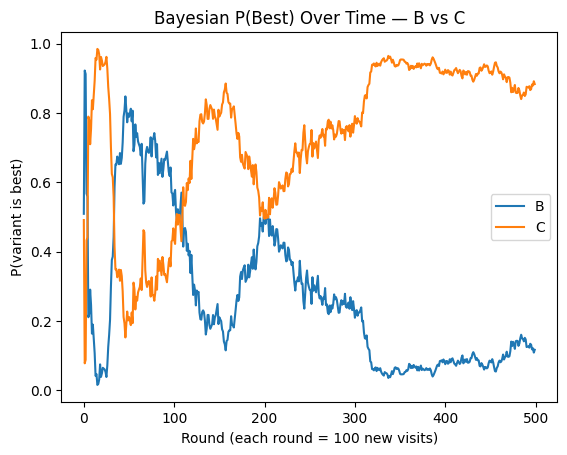

In [94]:
import matplotlib.pyplot as plt

# first lets run with 500 rounds
all_p_best_pair , _= run_bayesian_simulation(500, [0, 250, 500])

def plot_bayesian_rounds(rounds : int, all_p_best_pair):
    # unpack into all different variants
    all_p_best_pair = np.array(all_p_best_pair)
    all_best_pair_b, all_best_pair_c = all_p_best_pair[:, 0], all_p_best_pair[:, 1]
    xes = np.arange(0, rounds)
    plt.plot(xes, all_best_pair_b, label='B')
    plt.plot(xes, all_best_pair_c, label='C')
    plt.xlabel('Round (each round = 100 new visits)')
    plt.ylabel('P(variant is best)')
    plt.title('Bayesian P(Best) Over Time — B vs C')
    plt.legend()
    plt.show()

plot_bayesian_rounds(500, all_p_best_pair)

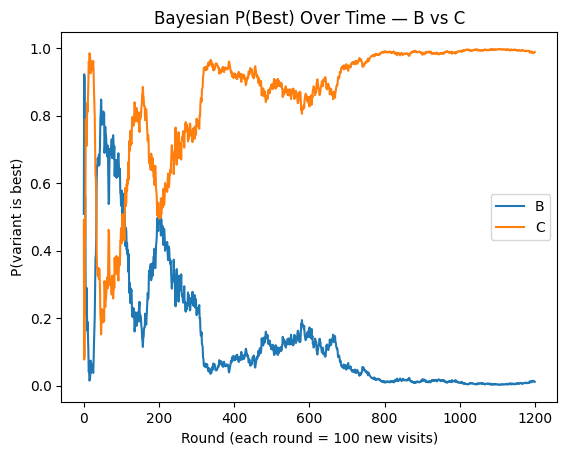

In [95]:
# we can see that there is alot of variance in the probabilities still so let's increase the amount of rounds to total the estimate 
# rounds needed from classic A/B testing
all_p_more, snapshots_more = run_bayesian_simulation(1200, [0, 250, 1199])
plot_bayesian_rounds(1200, all_p_more)

# as we can see it stablises

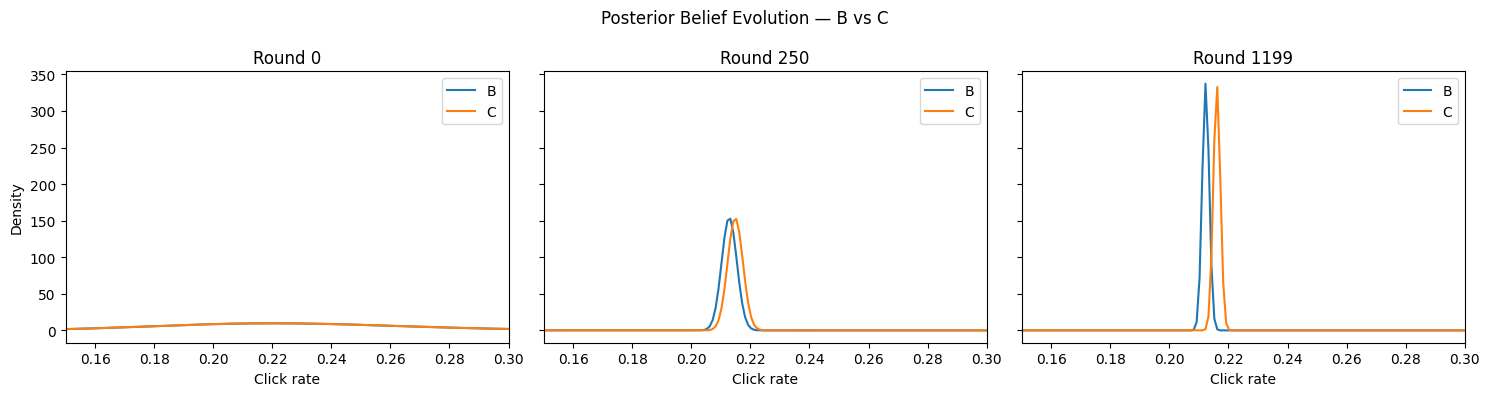

In [96]:
from scipy.stats import beta as beta_dist

# plot the probability distribution function at given checkpints of the no click and click counts
x = np.linspace(0, 1, 1000)
checkpoints = [0, 250, 1199]
fig, axes = plt.subplots(1, len(checkpoints), figsize=(15, 4), sharey=True)

for ax, cp in zip(axes, checkpoints):
    params = snapshots_more[cp]
    
    y_b = beta_dist.pdf(x, params['B']['alpha'], params['B']['beta'])
    y_c = beta_dist.pdf(x, params['C']['alpha'], params['C']['beta'])
    
    ax.plot(x, y_b, label='B')
    ax.plot(x, y_c, label='C')
    ax.set_title(f'Round {cp}')
    ax.set_xlabel('Click rate')
    ax.set_xlim(0.15, 0.30)
    ax.legend()

axes[0].set_ylabel('Density')
plt.suptitle('Posterior Belief Evolution — B vs C')
plt.tight_layout()
plt.show()

### Multi-Armed Bandits

In the previous iterations, we always served each variant an equal amount users each in the simulation. Though this is technically fair to each variant in some cases, it might be uneccesary to keep sending traffic to variants that are for sure not going to win. In multi-armed bandits, we tackle this exact problem by adjusting which variant gets more traffic while the test is running.

In [114]:
epsilon = 0.1
rng_multi = np.random.default_rng(1)
def serve_epsilon(options, click_rates):

    # general random number
    p = rng_multi.random()
    if p < epsilon:
        # serve a random variant
        return rng_multi.choice(options)
    else:
        return options[np.argmax(click_rates)]

In [115]:
# run each variant for 5 turns in the beginning
a, b, c = 0, 0, 0
epsilon_all_traffic = TrafficSimulator(true_ctrs=true_ctrs)
a = sum(epsilon_all_traffic.simulate_batch('A', 5)) / 5
b = sum(epsilon_all_traffic.simulate_batch('B', 5)) / 5
c = sum(epsilon_all_traffic.simulate_batch('C', 5)) / 5
all_click_rates = [a, b, c]

In [124]:
# lets start with three-way bandits
clicks = {'A' : 5*a, 'B' : 5*b, 'C' : 5*c}
attempts = {'A' : 5, 'B' : 5, 'C' : 5}
all_options = ['A', 'B', 'C']
regrets = []
# for regret tracking
best_ctr =  max(true_ctrs.values())
for i in range(1, 6000):
    # update decaying epsilon
    epsilon = max(0.01, 0.1 / math.sqrt(i))
    # get the variant we need
    variant = serve_epsilon(all_options, all_click_rates)
    attempts[variant] += 1
    # serve the variant
    res = epsilon_all_traffic.simulate_click(variant=variant)

    # update the clicks
    clicks[variant] += res

    ctr = clicks[variant] / attempts[variant]
    # update click rates
    all_click_rates[all_options.index(variant)] = ctr
    regrets.append(best_ctr - true_ctrs[variant])

cumulative_regret = np.cumsum(regrets)

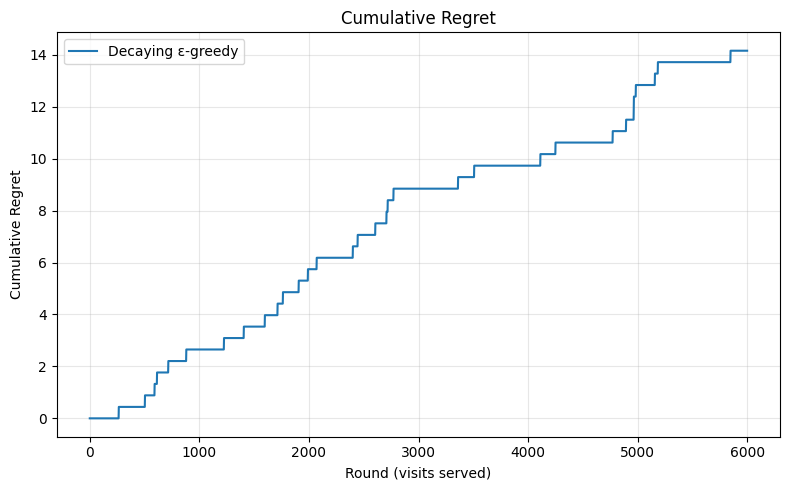

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(cumulative_regret, label='Decaying ε-greedy')

plt.xlabel('Round (visits served)')
plt.ylabel('Cumulative Regret')
plt.title('Cumulative Regret')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()